In [1]:
import geopandas as gpd
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap
from libpysal.weights import KNN
from sklearn.preprocessing import StandardScaler
from models.gpkg import GeoPackage

In [4]:
gpkg = GeoPackage()
gdf = gpkg.read_layer('vindex_1985_2000_godmode')
# se = gpkg.read_layer('sistemas_ecologicos_RS_hasenack')

In [21]:
biomas = gpkg.read_layer('biomas_rs_faixa_trans_final')

In [4]:
educ = gpkg.read_layer('test_educacao_regressao')

In [6]:
biomas['area_km²'] = round(biomas.geometry.area / 1e6, 2)

In [7]:
biomas['area_perc'] = round((biomas['area_km²'] / biomas['area_km²'].sum()) * 100, 2)

In [8]:
biomas[['bioma', 'area_km²', 'area_perc']]

,bioma,area_km²,area_perc
0,Pampa,166506.27,59.08
1,Mata atlântica,64494.33,22.89
2,Faixa de transição,50814.61,18.03


In [5]:
from tools.exposure import spatial_join_pampa
test = gdf.copy()
test = spatial_join_pampa(gdf, se, bioma_col='SISTEMA')
test.head()

,pol_id,nome_ti,etnia_nome,regeneration_%_se,degeneration_%_se,forest_cover_2023_%_se,bioma,forest_formation_se,grassland_se,soybean_se,...,se_score,ca_score,vulnerability_raw,vulnerability_index,vulnerability_category,ca_category_norm,se_category_norm,ex_category_norm,geometry,SISTEMA
0,0,0,0,65.798611,0.087977,44.041071,Faixa de transição,88.578745,0.000000,0.000000,...,0.059544,0.659546,0.330886,0.173388,Muito baixo,Muito Alta,Muito baixo,Baixo,MULTIPOLYGON Z (((5366397.945 6711242.732 -9.4...,Outras formacoes
1,1,Arakuã - Ka'aguy Mirim,Guarani,58.593750,0.016561,48.376481,Pampa,54.459335,38.770795,0.002557,...,0.022410,0.755521,0.243280,0.086327,Muito baixo,Excepcional,Muito baixo,Muito baixo,MULTIPOLYGON Z (((5287377.789 6653737.619 -9.4...,Campo misto de andropogoneas e compostas
2,2,Gãh Ré,Kaingang,24.242424,0.007519,67.241379,Pampa,43.548387,23.118280,0.000000,...,0.027959,0.286736,0.354776,0.197131,Baixo,Média,Muito baixo,Muito baixo,MULTIPOLYGON Z (((5276505.692 6670909.123 -9.4...,Campo misto de andropogoneas e compostas
3,3,0,0,24.855491,0.187500,14.124668,Pampa,0.000000,4.371217,0.000000,...,0.314801,0.113019,0.618445,0.459161,Alto,Muito baixa,Alto,Médio,MULTIPOLYGON Z (((5259479.817 6647130.844 -9.4...,Campo misto de andropogoneas e compostas
4,4,0,0,0.000000,0.174178,37.624861,Faixa de transição,84.016393,0.000000,0.000000,...,0.071527,0.440262,0.302029,0.144711,Muito baixo,Alta,Muito baixo,Muito baixo,MULTIPOLYGON Z (((5372998.368 6713607.226 -9.4...,Outras formacoes


In [6]:
# Calcular centroides das TIs (necessário para coordenadas)
# gdf = gdf.dropna(subset='TxAlfabetI')

gdf.geometry = gdf.geometry.buffer(gdf.dist_buf)
coords = np.array(list(zip(gdf.centroid.x, gdf.centroid.y)))
gdf['soybean'] = gdf['soybean_ex'] + gdf['soybean_se']

cols = ['soybean', "est_fundiaria"]

# Definir variáveis
y = gdf["vulnerability_index"].values.reshape((-1,1))  # variável dependente
X = gdf[cols].values

# Normalizar X (boa prática para GWR)
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [7]:
bw = Sel_BW(coords, y, X).search()
print("Bandwidth ótimo:", bw)


Bandwidth ótimo: 56.0


In [8]:
gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())


Model type                                                         Gaussian
Number of observations:                                                 139
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                              6.421
Log-likelihood:                                                      16.468
AIC:                                                                -26.936
AICc:                                                               -24.638
BIC:                                                               -664.667
R2:                                                                   0.312
Adj. R2:                                                              0.302

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [46]:
gdf

,pol_id,nome_ti,etnia_nome,regeneration_%_se,degeneration_%_se,forest_cover_2023_%_se,bioma,forest_formation_se,grassland_se,soybean_se,...,vulnerability_index,vulnerability_category,ca_category_norm,se_category_norm,ex_category_norm,geometry,SISTEMA,soybean,coef_est_fundiaria,R2_local
0,0,0,0,65.798611,0.087977,44.041071,Faixa de transição,88.578745,0.000000,0.000000,...,0.173388,Muito baixo,Muito Alta,Muito baixo,Baixo,"POLYGON ((5369759.124 6712187.768, 5369785.75 ...",Outras formacoes,0.008867,0.220779,0.188520
1,1,Arakuã - Ka'aguy Mirim,Guarani,58.593750,0.016561,48.376481,Pampa,54.459335,38.770795,0.002557,...,0.086327,Muito baixo,Excepcional,Muito baixo,Muito baixo,"POLYGON ((5282379.246 6654414.43, 5282367.711 ...",Campo misto de andropogoneas e compostas,0.003919,0.342457,0.307836
2,2,Gãh Ré,Kaingang,24.242424,0.007519,67.241379,Pampa,43.548387,23.118280,0.000000,...,0.197131,Baixo,Média,Muito baixo,Muito baixo,"POLYGON ((5275985.396 6674100.7, 5276037.612 6...",Campo misto de andropogoneas e compostas,0.000000,0.375656,0.412978
3,3,0,0,24.855491,0.187500,14.124668,Pampa,0.000000,4.371217,0.000000,...,0.459161,Alto,Muito baixa,Alto,Médio,"POLYGON ((5256466.037 6644961.235, 5256195.739...",Campo misto de andropogoneas e compostas,0.000000,0.385167,0.414264
4,4,0,0,0.000000,0.174178,37.624861,Faixa de transição,84.016393,0.000000,0.000000,...,0.144711,Muito baixo,Alta,Muito baixo,Muito baixo,"POLYGON ((5369606.322 6713330.32, 5369609.986 ...",Outras formacoes,0.000000,0.225430,0.193266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,133,0,0,0.000000,0.000000,0.000000,Mata atlântica,0.000000,0.000000,0.000000,...,0.506709,Alto,Muito baixa,Baixo,Crítico,"POLYGON ((5313782.356 6714958.963, 5313783.938...",Outras formacoes,0.005768,0.260928,0.318920
137,135,0,0,10.400000,0.000000,18.421053,Mata atlântica,46.405229,0.000000,0.000000,...,0.719952,Crítico,Média,Alto,Crítico,"POLYGON ((5201275.597 6725345.332, 5201259.105...",Outras formacoes,0.314656,0.556574,0.186540
138,137,0,0,8.695652,0.617925,18.693694,Mata atlântica,33.498759,0.000000,0.000000,...,0.557385,Muito Alto,Alta,Alto,Crítico,"POLYGON ((5235360.816 6733361.9, 5235344.854 6...",Outras formacoes,0.047502,0.534102,0.276584
139,138,0,0,9.713024,0.142594,38.143004,Mata atlântica,57.136895,0.000000,0.040307,...,0.505036,Alto,Excepcional,Crítico,Médio,"POLYGON ((5272782.233 6797496.421, 5272779.399...",Outras formacoes,0.042246,0.492531,0.548600


In [9]:
# Coeficientes para cada variável
for i, var in enumerate(cols):
    gdf[f"coef_{var}"] = gwr_results.params[:, i]

# R² local
gdf["R2_local"] = gwr_results.localR2


In [11]:
gdf.groupby("bioma")[[f"coef_{v}" for v in cols]].mean()

,coef_mining_threat_area_ratio_ex
bioma,
Faixa de transição,0.492118
Mata atlântica,0.477531
Pampa,0.299352


In [12]:
gdf.groupby(['SISTEMA']).size()

SISTEMA
Campo arbustivo                              3
Campo com barba-de-bode                      6
Campo graminoso                              2
Campo litoraneo                             17
Campo misto de andropogoneas e compostas    32
Floresta Estacional                          9
Outras formacoes                            72
dtype: int64

In [147]:
gdf['urban_area_ex'].loc[gdf['SISTEMA'] != 'Campo com barba-de-bode'].describe()

count    135.000000
mean       0.130579
std        0.225941
min        0.000000
25%        0.003072
50%        0.014680
75%        0.139182
max        1.000000
Name: urban_area_ex, dtype: float64

In [138]:
gdf['coef_soybean_ex'].describe()

count    141.000000
mean       0.378230
std        0.075002
min        0.287734
25%        0.314782
50%        0.352607
75%        0.434366
max        0.551928
Name: coef_soybean_ex, dtype: float64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scatter_gwr(data: gpd.GeoDataFrame, x: str, y: str, hue: str, region: str):# Scatter plot de soja vs vulnerabilidade, colorido pelo coeficiente GWR
    plt.figure(figsize=(12, 6))
    legend_dict = {
        "soybean": "Soja",
        "urban_area": "Áreas urbanas",
        "forest_plantation": "Silvicultura",
        "silvicultura": "Silvicultura",
        "agropec": "Agropecuária",
        "mining": "Mineração",
        "roads": "Estradas",
        "heat": "Incêndios",
        "proximity_index": "Índice de proximidade a CR/CTL",
        "txalfabeti_imputed": "Taxa de Alfabetismo",
        "regeneration_%_total": "Regeneração de vegetação nativa",
        "est_fundiaria": "Estrutura fundiária"
    }
    y_column = {
        "vulnerability_index": "Índice de Vulnerabilidade",
        "ca_score": "Capacidade Adaptativa",
        "ex_score": "Exposição",
        "se_score": "Sensibilidade"
    }
    for k, v in legend_dict.items():
        if k in x:
            x_leg = v
    if "ex" in x:
        x_leg = x_leg + " (exposição)"
    elif "se" in x:
        x_leg = x_leg + " (sensibilidade)"
    else:
        x_leg = x_leg
    sns.scatterplot(
        data=data,
        x=x,
        y=y,
        hue=hue,  # coeficiente local
        style=region,         # diferentes símbolos por sistema
        palette='coolwarm',
        s=100
    )

    plt.xlabel(x_leg)
    plt.ylabel(y_column.get(y, 0))
    plt.title(f'Relação entre {x_leg} e {y_column.get(y, 0)} por Sistema (colorido pelo coeficiente GWR)')
    # plt.colorbar()  # legenda da cor
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


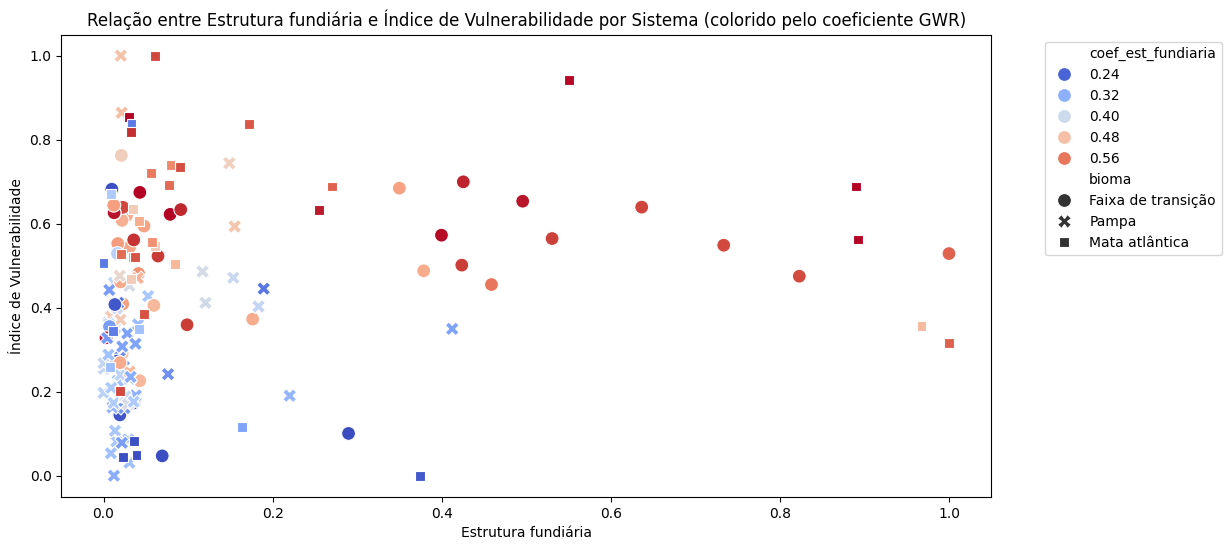

In [50]:
plot_scatter_gwr(gdf, 'est_fundiaria', 'vulnerability_index', 'coef_est_fundiaria', 'bioma')

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches
import contextily as ctx

def plot_gwr_results(gdf, gwr_model, variable_names, coords, figsize=(18, 14), add_basemap=True):
    """
    Função para plotar resultados do modelo GWR com basemap do OpenStreetMap.
    
    Parâmetros:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame com a geometria original dos dados
    gwr_model : objeto GWRResults do mgwr
        Modelo GWR ajustado com mgwr
    variable_names : list
        Lista com os nomes das variáveis independentes
    coords : array
        Coordenadas dos pontos utilizados no modelo
    figsize : tuple, optional
        Tamanho da figura (padrão: (18, 14))
    add_basemap : bool, optional
        Se True, adiciona basemap do OpenStreetMap (padrão: True)
    """
    
    # Configuração do estilo dos plots
    plt.style.use('default')
    
    # Verificar se o GeoDataFrame está em coordenadas geográficas
    if gdf.crs is None:
        print("Aviso: O GeoDataFrame não tem CRS definido. Definindo como WGS84 (EPSG:4326).")
        gdf = gdf.set_crs(epsg=4326)
    
    # Reprojetar para Web Mercator (EPSG:3857) para compatibilidade com contextily
    gdf_web_mercator = gdf.to_crs(epsg=3857)
    
    # Criar figura com subplots
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle('Resultados da Regressão Geograficamente Ponderada (GWR)', fontsize=16, fontweight='bold')
    
    # 1. MAPA DOS COEFICIENTES PARA UMA VARIÁVEL EXEMPLAR
    coef_var = gwr_model.params[:, 1]  # Coeficientes para a primeira variável (após intercepto)
    gdf_web_mercator['coef_var1'] = coef_var
    
    ax1 = axes[0, 0]
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    
    # Plotar os dados
    gdf_web_mercator.plot(column='coef_var1', ax=ax1, legend=True, cax=cax,
                         cmap='RdYlBu_r', edgecolor='black', linewidth=0.8,
                         alpha=0.8, legend_kwds={'label': f'Coeficiente {variable_names[1]}'})
    
    # Adicionar basemap
    if add_basemap:
        try:
            ctx.add_basemap(ax1, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
        except Exception as e:
            print(f"Erro ao adicionar basemap: {e}")
    
    ax1.set_title(f'Coeficiente: {variable_names[1]}', fontweight='bold')
    ax1.set_axis_off()
    
    # 2. MAPA DOS VALORES AJUSTADOS (Y hat)
    gdf_web_mercator['y_pred'] = gwr_model.predy
    ax2 = axes[0, 1]
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    
    gdf_web_mercator.plot(column='y_pred', ax=ax2, legend=True, cax=cax,
                         cmap='viridis', edgecolor='black', linewidth=0.8,
                         alpha=0.8, legend_kwds={'label': 'Valores Preditos'})
    
    if add_basemap:
        try:
            ctx.add_basemap(ax2, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
        except:
            pass
    
    ax2.set_title('Valores Preditos (Ŷ)', fontweight='bold')
    ax2.set_axis_off()
    
    # 3. MAPA DOS RESÍDUOS
    gdf_web_mercator['residuals'] = gwr_model.resid_response
    ax3 = axes[0, 2]
    divider = make_axes_locatable(ax3)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    
    gdf_web_mercator.plot(column='residuals', ax=ax3, legend=True, cax=cax,
                         cmap='RdBu_r', edgecolor='black', linewidth=0.8,
                         alpha=0.8, legend_kwds={'label': 'Resíduos'})
    
    if add_basemap:
        try:
            ctx.add_basemap(ax3, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
        except:
            pass
    
    ax3.set_title('Resíduos do Modelo', fontweight='bold')
    ax3.set_axis_off()
    
    # 4. MAPA DO R² LOCAL
    try:
        local_r2 = gwr_model.localR2
    except AttributeError:
        y_mean = np.mean(gwr_model.predy)
        SST_local = np.sum((gwr_model.predy - y_mean)**2)
        SSE_local = np.sum(gwr_model.resid_response**2)
        local_r2 = 1 - (SSE_local / SST_local)
    
    gdf_web_mercator['local_r2'] = local_r2
    ax4 = axes[1, 0]
    divider = make_axes_locatable(ax4)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    
    gdf_web_mercator.plot(column='local_r2', ax=ax4, legend=True, cax=cax,
                         cmap='RdYlGn', vmin=0, vmax=1, edgecolor='black', linewidth=0.8,
                         alpha=0.8, legend_kwds={'label': 'R² Local'})
    
    if add_basemap:
        try:
            ctx.add_basemap(ax4, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
        except:
            pass
    
    ax4.set_title('R² Local', fontweight='bold')
    ax4.set_axis_off()
    
    # 5. MAPA DA INFLUÊNCIA LOCAL (leverage)
    try:
        influence = gwr_model.influence
        gdf_web_mercator['influence'] = influence
        ax5 = axes[1, 1]
        divider = make_axes_locatable(ax5)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        
        gdf_web_mercator.plot(column='influence', ax=ax5, legend=True, cax=cax,
                             cmap='OrRd', edgecolor='black', linewidth=0.8,
                             alpha=0.8, legend_kwds={'label': 'Influência'})
        
        if add_basemap:
            try:
                ctx.add_basemap(ax5, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
            except:
                pass
        
        ax5.set_title('Influência Local (Leverage)', fontweight='bold')
        ax5.set_axis_off()
    except AttributeError:
        ax5 = axes[1, 1]
        ax5.text(0.5, 0.5, 'Informação de influência\nnão disponível', 
                ha='center', va='center', fontsize=12, transform=ax5.transAxes)
        ax5.set_title('Influência Local', fontweight='bold')
        ax5.set_axis_off()
    
    # 6. ESTATÍSTICAS DO MODELO E BANDWIDTH
    ax6 = axes[1, 2]
    
    bandwidth = gwr_model.bw if hasattr(gwr_model, 'bw') else 'N/A'
    
    model_stats = f"""
    Estatísticas do Modelo:
    -----------------------
    R² Global: {gwr_model.R2:.3f}
    R² Ajustado: {gwr_model.adj_R2:.3f}
    AICc: {gwr_model.aicc:.2f}
    Bandwidth: {bandwidth}
    Nº Observações: {gwr_model.n}
    """
    
    ax6.text(0.5, 0.5, model_stats, ha='center', va='center', 
             fontsize=10, transform=ax6.transAxes, 
             bbox=dict(facecolor='white', alpha=0.9, boxstyle='round'))
    
    ax6.set_title('Estatísticas do Modelo', fontweight='bold')
    ax6.set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    # Plotar coeficientes para todas as variáveis com basemap
    plot_all_coefficients(gdf, gwr_model, variable_names, add_basemap)

def plot_all_coefficients(gdf, gwr_model, variable_names, add_basemap=True):
    """
    Plota mapas de coeficientes para todas as variáveis do modelo GWR com basemap.
    """
    # Reprojetar para Web Mercator
    epsg_3857 = 3857
    gdf_web_mercator = gdf.to_crs(epsg=3857) if gdf.crs != epsg_3857 else gdf
    
    n_vars = len(variable_names)
    n_cols = min(3, n_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    fig.suptitle('Coeficientes GWR por Variável com OpenStreetMap', fontsize=16, fontweight='bold')
    
    if n_rows * n_cols == 1:
        axes = np.array([axes])
    
    axes = axes.flatten()
    
    for i, var_name in enumerate(variable_names):
        if i >= len(axes):
            break
            
        ax = axes[i]
        coef_values = gwr_model.params[:, i]  # Coeficientes para cada variável
        
        gdf_temp = gdf_web_mercator.copy()
        gdf_temp['coef'] = coef_values
        
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        
        # Plotar coeficientes
        plot = gdf_temp.plot(column='coef', ax=ax, legend=True, cax=cax,
                           cmap='RdYlBu_r', edgecolor='black', linewidth=0.8,
                           alpha=0.8, legend_kwds={'label': f'Coef: {var_name}'})
        
        # Adicionar basemap
        if add_basemap:
            try:
                ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.6)
            except Exception as e:
                print(f"Erro ao adicionar basemap: {e}")
        
        ax.set_title(f'Coeficiente: {var_name}', fontweight='bold')
        ax.set_axis_off()
        
        # Adicionar estatísticas descritivas
        stats_text = f'Média: {coef_values.mean():.3f}\nStd: {coef_values.std():.3f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    # Ocultar eixos extras
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_gwr_diagnostics(gwr_model, variable_names):
    """
    Função para plotar diagnósticos adicionais do modelo GWR.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Diagnósticos do Modelo GWR', fontsize=16, fontweight='bold')
    
    # 1. Distribuição dos coeficientes
    for i, var_name in enumerate(variable_names):
        axes[0, 0].hist(gwr_model.params[:, i], alpha=0.7, label=var_name, bins=20)
    axes[0, 0].set_title('Distribuição dos Coeficientes')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Resíduos vs Valores Preditos
    axes[0, 1].scatter(gwr_model.predy, gwr_model.resid_response, alpha=0.6)
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('Valores Preditos')
    axes[0, 1].set_ylabel('Resíduos')
    axes[0, 1].set_title('Resíduos vs Valores Preditos')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. QQ-Plot dos resíduos
    from scipy import stats
    stats.probplot(gwr_model.resid_response, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('QQ-Plot dos Resíduos')
    
    # 4. Mapa de significância dos coeficientes
    try:
        t_values = gwr_model.filter_tvals(alpha=0.05)
        sig_mask = np.abs(t_values[:, 1]) > 1.96
        axes[1, 1].hist(sig_mask.astype(int), bins=3, alpha=0.7)
        axes[1, 1].set_title('Significância dos Coeficientes\n(1=Significativo, 0=Não)')
        axes[1, 1].set_xlabel('Significativo')
        axes[1, 1].set_ylabel('Frequência')
    except:
        axes[1, 1].text(0.5, 0.5, 'Testes de significância\nnão disponíveis', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Significância dos Coeficientes')
    
    plt.tight_layout()
    plt.show()

def plot_gwr_spatial_distribution(gdf, gwr_model, variable_names, add_basemap=True):
    """
    Plot especializado mostrando a distribuição espacial dos coeficientes mais importantes.
    """
    # Reprojetar para Web Mercator
    gdf_web_mercator = gdf.to_crs(epsg=3857)
    
    # Encontrar variável com maior variabilidade espacial
    coef_std = np.std(gwr_model.params, axis=0)
    most_variable_idx = np.argmax(coef_std[1:]) + 1  # Pular intercepto
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plotar coeficiente com maior variabilidade
    gdf_web_mercator['main_coef'] = gwr_model.params[:, most_variable_idx]
    
    plot = gdf_web_mercator.plot(column='main_coef', ax=ax, 
                               cmap='RdYlBu_r', edgecolor='black', linewidth=1,
                               alpha=0.8, legend=True,
                               legend_kwds={'label': f'Coeficiente: {variable_names[most_variable_idx]}',
                                           'orientation': 'horizontal'})
    
    # Adicionar basemap
    if add_basemap:
        try:
            ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
        except Exception as e:
            print(f"Erro ao adicionar basemap: {e}")
    
    ax.set_title(f'Distribuição Espacial do Coeficiente: {variable_names[most_variable_idx]}\n'
                f'(Variável com maior variabilidade espacial)', fontweight='bold')
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

# Exemplo de uso completo:
def run_complete_gwr_analysis(gdf, dependent_var, independent_vars, coords, add_basemap=True):
    """
    Função completa para executar análise GWR e visualizar resultados com basemap.
    """
    from mgwr.sel_bw import Sel_BW
    from mgwr.gwr import GWR
    
    # Verificar e definir CRS se necessário
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
        print("CRS definido como WGS84 (EPSG:4326)")
    
    # Preparar dados
    y = gdf[dependent_var].values.reshape(-1, 1)
    X = gdf[independent_vars].values
    
    # Selecionar bandwidth ótimo
    selector = Sel_BW(coords, y, X)
    bw = selector.search(verbose=True)
    
    print(f"Bandwidth ótimo selecionado: {bw}")
    
    # Ajustar modelo GWR
    gwr_model = GWR(coords, y, X, bw).fit()
    
    # Nomes das variáveis
    variable_names = ['Intercepto'] + independent_vars
    
    # Plotar resultados
    plot_gwr_results(gdf, gwr_model, variable_names, coords, add_basemap=add_basemap)
    plot_gwr_diagnostics(gwr_model, variable_names)
    plot_gwr_spatial_distribution(gdf, gwr_model, variable_names, add_basemap=add_basemap)
    
    return gwr_model

# Instalação das dependências necessárias (executar no terminal)
# pip install contextily mgwr geopandas matplotlib numpy

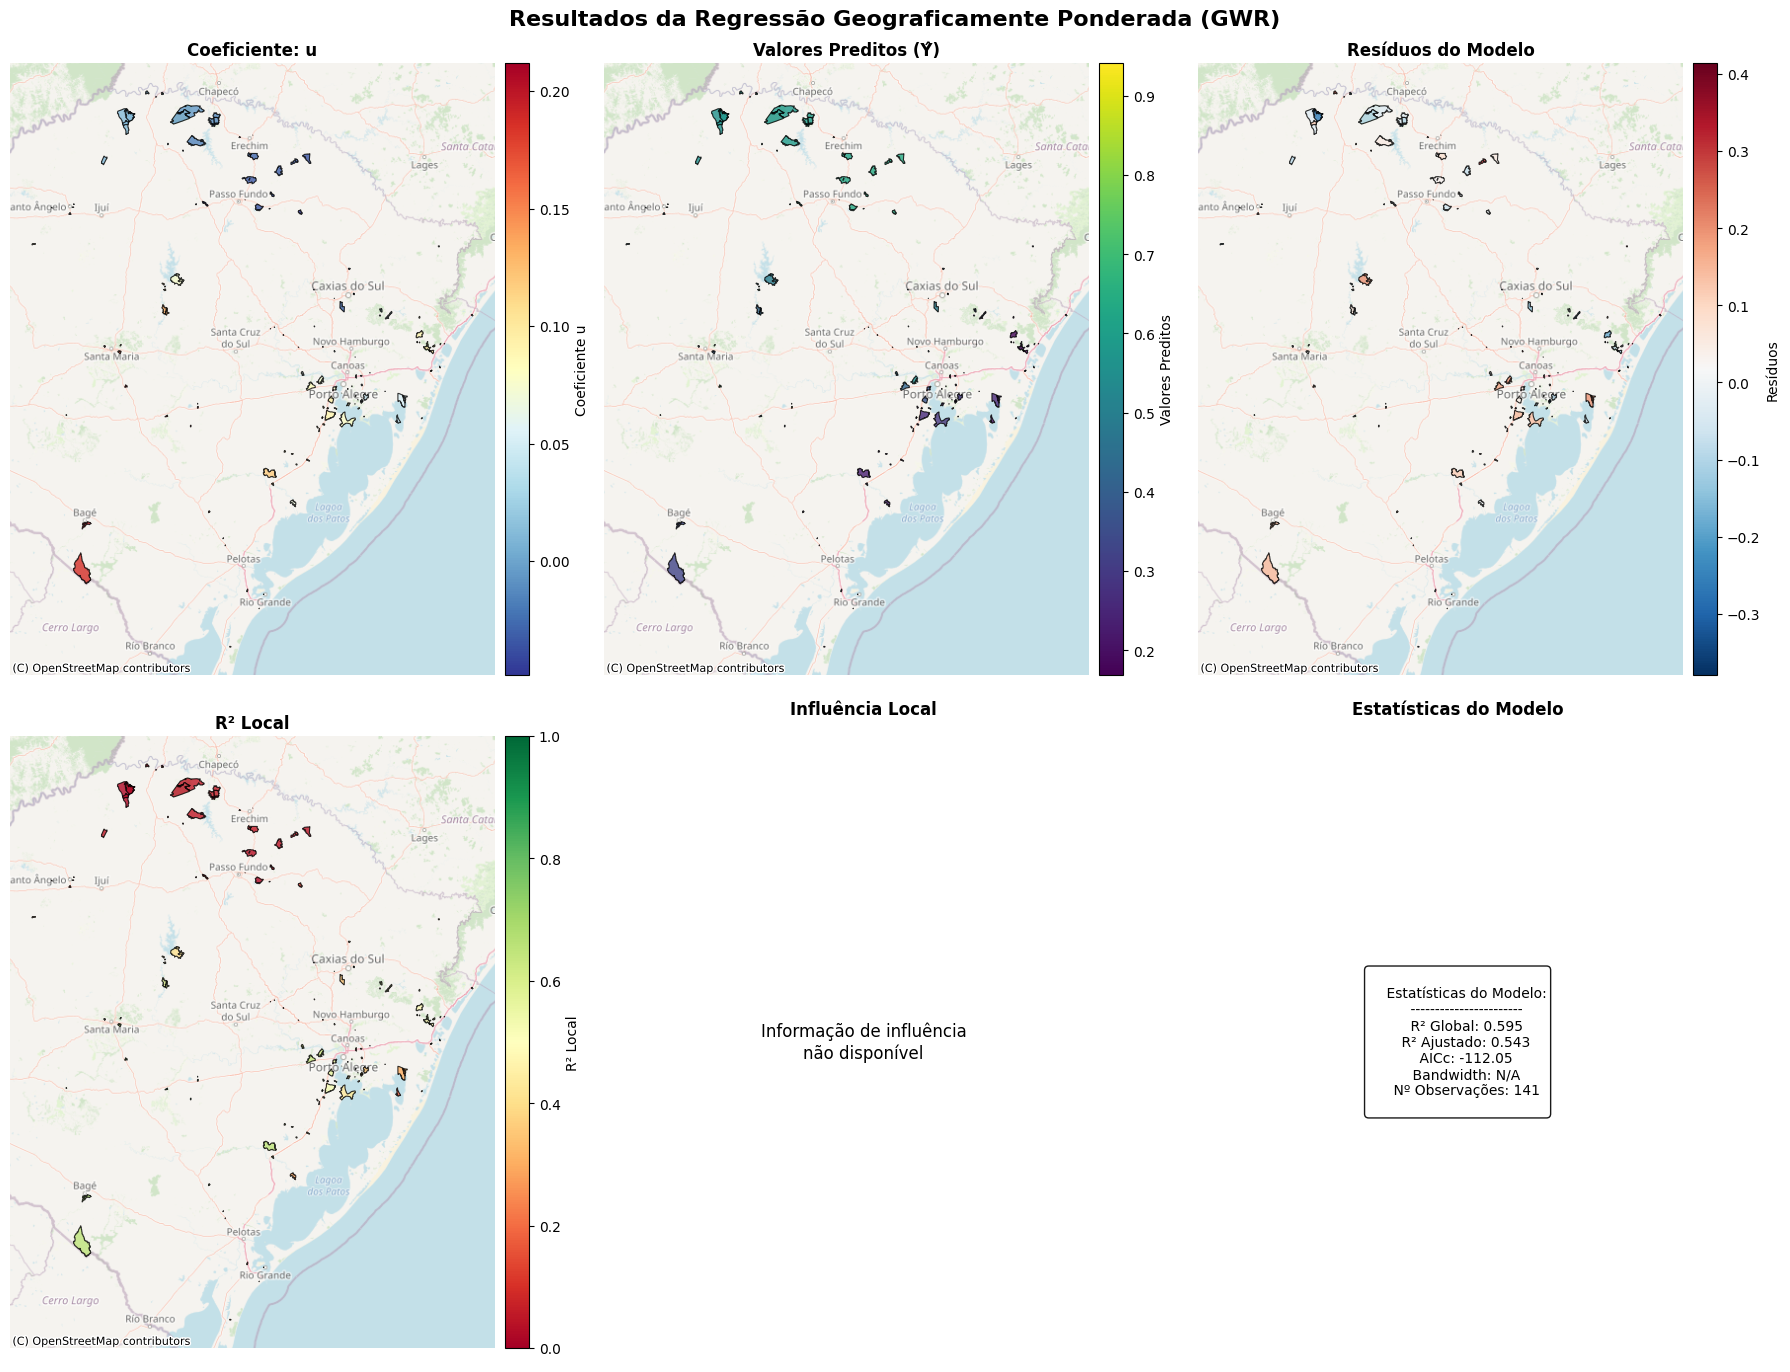

IndexError: index 2 is out of bounds for axis 1 with size 2

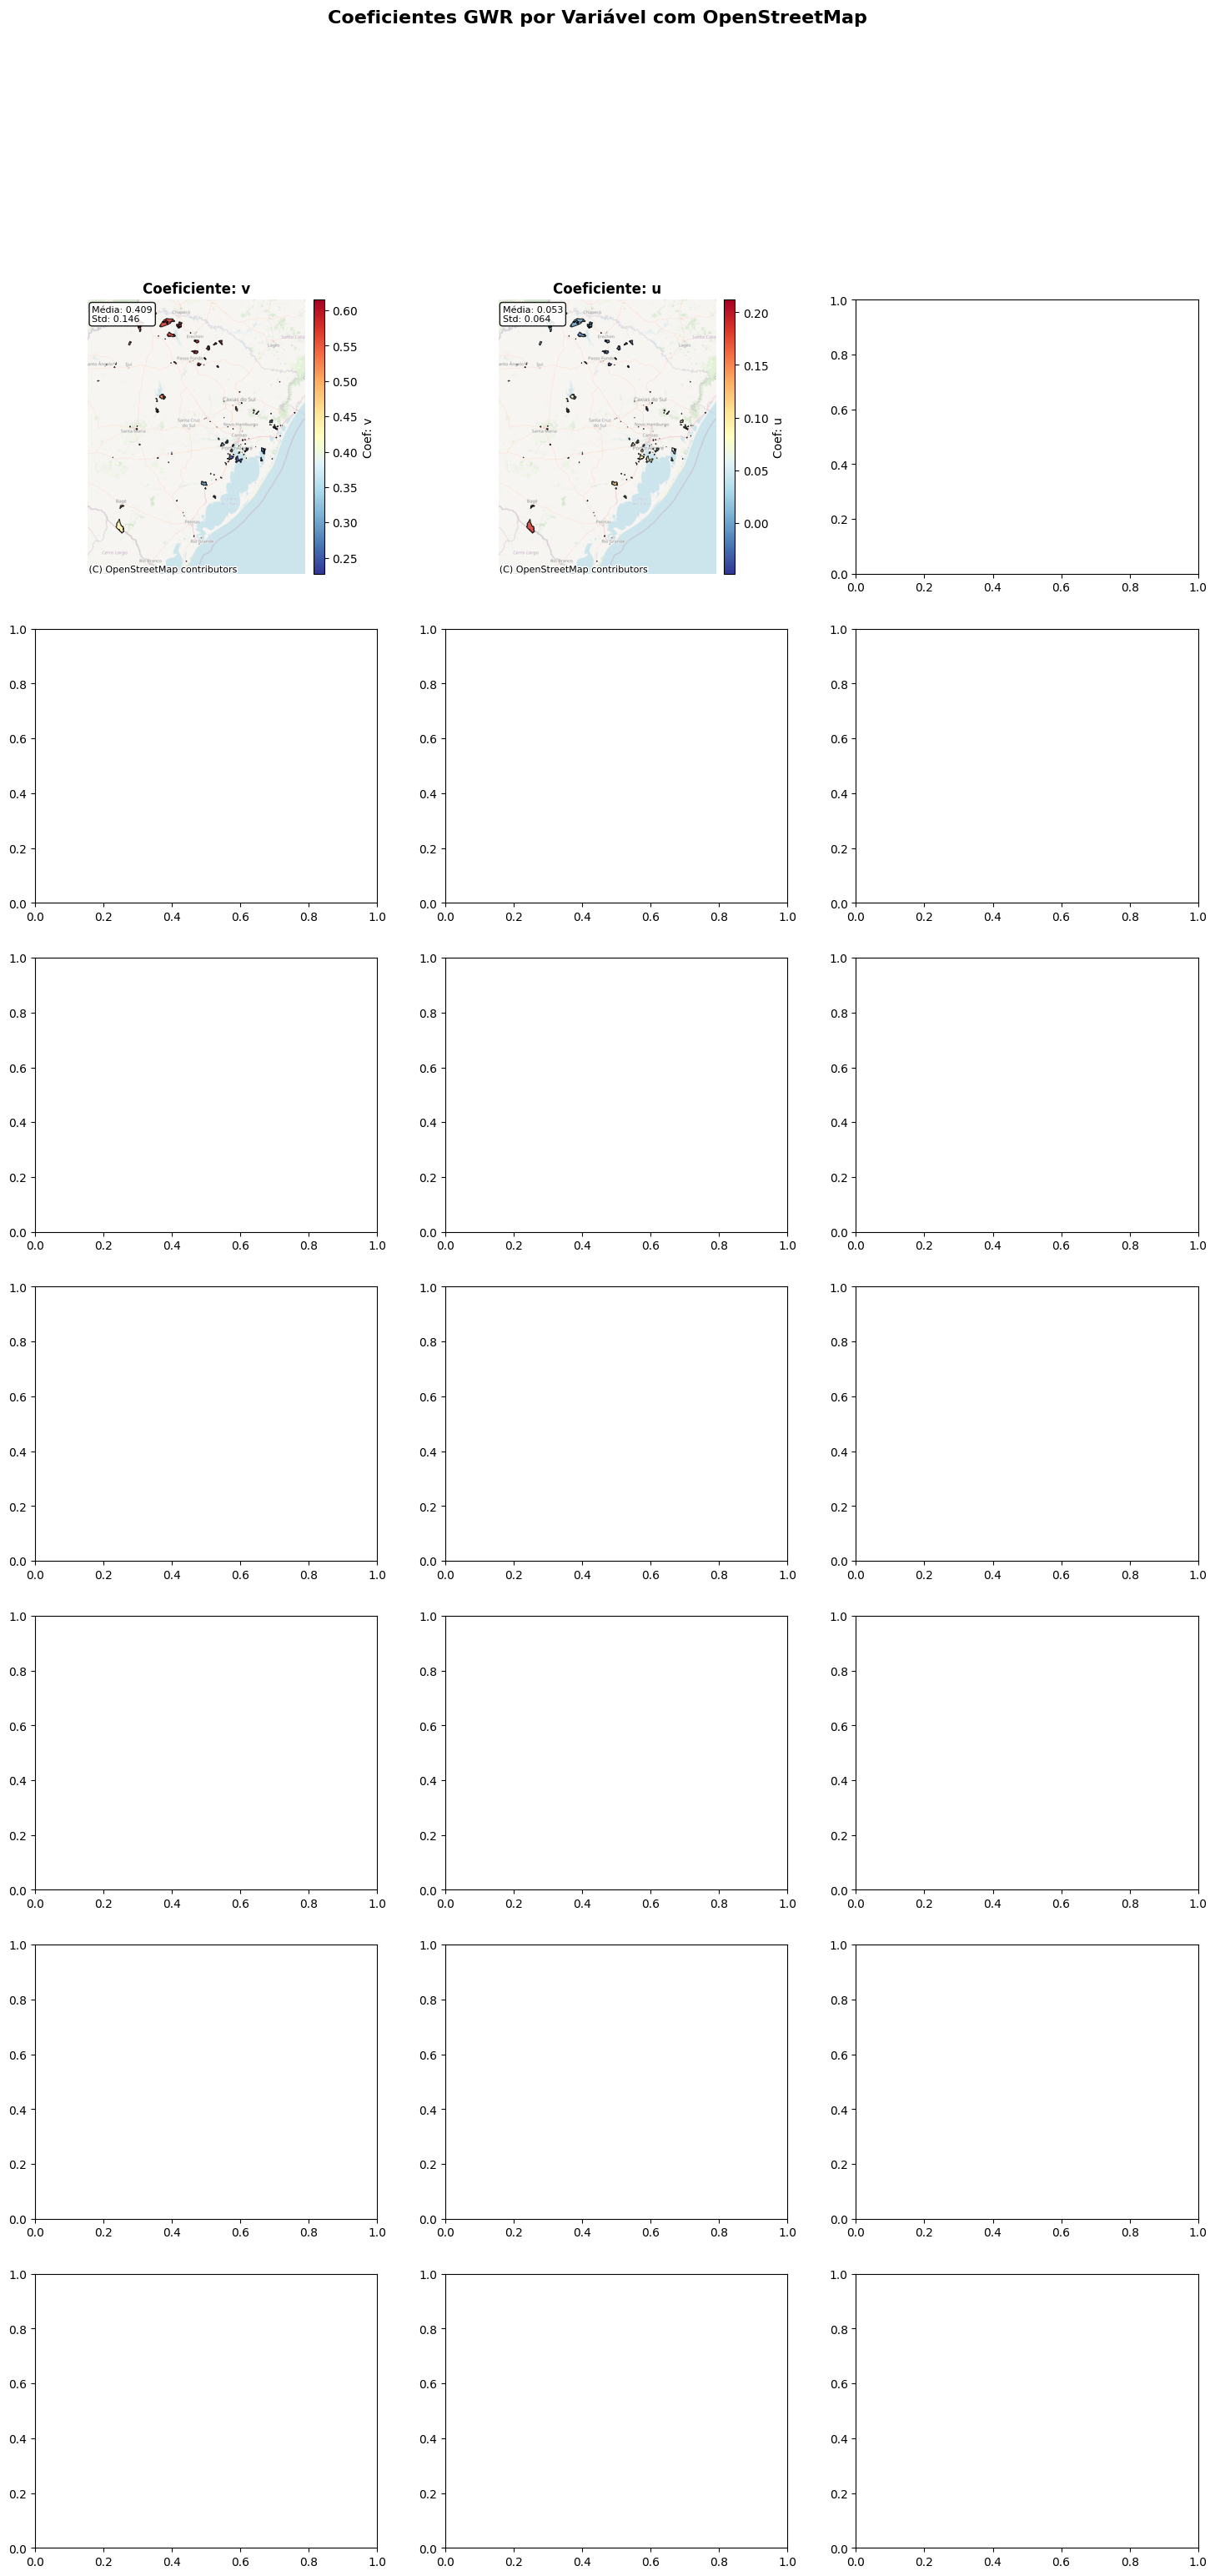

In [18]:
plot_gwr_results(gdf, gwr_results, 'vulnerability_index', coords)
# gwr_model.var